In [ ]:
!pip install ultralytics opencv-python

: 

In [1]:
from ultralytics import YOLO
import torch
import os
import cv2

In [3]:
device = 0 if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: 0


In [4]:
model = YOLO("yolov8m.pt")  # or yolov8n.pt for faster testing
print("Model loaded successfully")

Model loaded successfully


In [7]:


# Get project root (go one level up from notebook/)
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Define paths
DATA_YAML = os.path.join(BASE_DIR, "data", "dir__patht.yaml")
PROJECT_PATH = os.path.join(BASE_DIR, "model", "runs")

print("Base Dir:", BASE_DIR)
print("YAML Path:", DATA_YAML)
print("Project Path:", PROJECT_PATH)

Base Dir: d:\Animal detection Model
YAML Path: d:\Animal detection Model\data\dir__patht.yaml
Project Path: d:\Animal detection Model\model\runs


In [8]:
results = model.train(
    data="../data/dir__patht.yaml",  # adjust path if needed
    epochs=50,
    imgsz=640,
    batch=8,
    device=device,
    workers=2,
    patience=10,
    project= PROJECT_PATH,
    name="animal_model",
    exist_ok=True
)

print("Training completed")

Ultralytics 8.4.30  Python-3.14.3 torch-2.12.0.dev20260327+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/dir__patht.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=animal_model, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=

In [9]:
metrics = model.val()
print("Validation results:")
print(metrics)

Ultralytics 8.4.30  Python-3.14.3 torch-2.12.0.dev20260327+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
Model summary (fused): 93 layers, 25,847,866 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 435.455.3 MB/s, size: 52.2 KB)
val: Scanning D:\Animal detection Model\data\valid\labels.cache... 2999 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2999/2999 967.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 188/188 3.5it/s 54.1s0.3ss
                   all       2999       4076      0.935      0.936      0.968      0.885
                bagula        200        230      0.982      0.958      0.987      0.915
                  bear        193        253      0.913      0.941      0.971      0.905
                  boar        155        174      0.924      0.937      0.975      0.913
               buffalo        219        246      0.854      0.894       0.91   

In [11]:
%pip install pandas

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.9 MB 8.8 MB/s eta 0:00:02
   ----------- ---------------------------- 2.9/9.9 MB 8.2 MB/s eta 0:00:01
   ---------------------- ----------------- 5.5/9.9 MB 9.9 MB/s eta 0:00:01
   ----------------------------- ---------- 7.3/9.9 MB 9.6 MB/s eta 0:00:01
   ----------------------------------- ---- 8.7/9.9 MB 8.8 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 8.7 MB/s  0:00:01

   ---------------------------------------- 0/2 [tzdata]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   ------------------

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Path to your results.csv
csv_path = "../model/runs/animal_model/results.csv"

# Load data
df = pd.read_csv(csv_path)

# Show columns (optional)
print(df.columns)

# Plot Accuracy (mAP)
plt.figure()
plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@0.5')
plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Over Epochs")
plt.legend()
plt.grid()

plt.show()

Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2', 'lr/pg3', 'lr/pg4', 'lr/pg5', 'lr/pg6',
       'lr/pg7'],
      dtype='str')


<Figure size 640x480 with 1 Axes>

In [16]:
best_model_path = "../model/runs/animal_model/weights/best.pt"

trained_model = YOLO(best_model_path)

trained_model.export(
    format="onnx",
    imgsz=640,
    dynamic=True,
    simplify=True,
    opset=12
)

print("ONNX model exported")

Ultralytics 8.4.30  Python-3.14.3 torch-2.12.0.dev20260327+cu128 CPU (13th Gen Intel Core i7-13700HX)
 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 93 layers, 25,847,866 parameters, 0 gradients, 78.7 GFLOPs

PyTorch: starting from '..\model\runs\animal_model\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 18, 8400) (49.6 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
   ---------------------------------------- 0.0/209.6 MB ? eta -:--:--
   ---------------------------------------- 1.0/209.6 MB 6.8 MB/s eta 0:00:31
   ---------------------------------------- 1.6/209.6 MB 5.7 MB/s eta 0:00:37
   ---------------------------------------- 2.4/209.6 MB 4.0 MB/s eta 0:00:52
    --------------------------------------- 3.1/209.6 MB 4.2 MB/s eta 0:00:50
    ---------------------

In [2]:
model = YOLO("../model/runs/animal_model/weights/best.pt")
print("Trained model loaded")

Trained model loaded


In [ ]:
results = model.predict(
    source="../test_images",  # folder or single image
    imgsz=640,
    conf=0.4,
    save=True,
    project="../predictions",
    name="results",
    exist_ok=True
)

print("Prediction done")


image 1/1 d:\Animal detection Model\notebook\..\test_images\bear-469-_jpg.rf.4f0f1d16003b61860331b64d2a8cc033.jpg: 640x640 1 bear, 106.2ms
Speed: 3.0ms preprocess, 106.2ms inference, 4.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to D:\Animal detection Model\notebook\runs\predictions\results\results
Prediction done


In [24]:
# Generate predictions
model.predict(
    source="../test_images",
    project="../predictions",
    name="results",
    save=True
)


image 1/1 d:\Animal detection Model\notebook\..\test_images\bear-469-_jpg.rf.4f0f1d16003b61860331b64d2a8cc033.jpg: 640x640 1 bear, 142.1ms
Speed: 4.5ms preprocess, 142.1ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to D:\Animal detection Model\notebook\runs\predictions\results


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'bagula', 1: 'bear', 2: 'boar', 3: 'buffalo', 4: 'cow', 5: 'crow', 6: 'deer', 7: 'hornbill', 8: 'lion', 9: 'monkey', 10: 'pigeon', 11: 'sarus', 12: 'sparrow', 13: 'tiger'}
 obb: None
 orig_img: array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        ...,
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
   

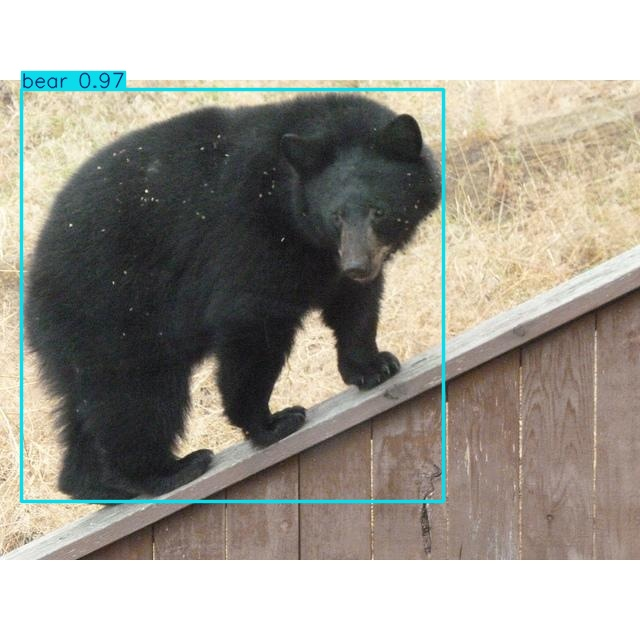

In [4]:
import os
from IPython.display import display
from PIL import Image

img_path = "runs/predictions/results"

# Create folder
os.makedirs(img_path, exist_ok=True)

# Check files
files = os.listdir(img_path)

if files:
    display(Image.open(os.path.join(img_path, files[0])))
else:
    print("⚠️ Folder is empty, no images to display")

In [3]:
cap = cv2.VideoCapture(0)

print("Press 'q' to exit")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame)
    annotated = results[0].plot()

    cv2.imshow("YOLO Detection", annotated)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Press 'q' to exit

0: 480x640 (no detections), 653.4ms
Speed: 153.3ms preprocess, 653.4ms inference, 15.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 553.2ms
Speed: 3.4ms preprocess, 553.2ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 540.6ms
Speed: 2.1ms preprocess, 540.6ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 cow, 507.5ms
Speed: 2.0ms preprocess, 507.5ms inference, 8.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 buffalos, 594.6ms
Speed: 5.6ms preprocess, 594.6ms inference, 2.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 618.2ms
Speed: 4.4ms preprocess, 618.2ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 cow, 585.6ms
Speed: 2.6ms preprocess, 585.6ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 cow, 559.1ms
Speed: 1.8ms preprocess, 559.1ms